# Dit Notebook bevat een nadere onderbouwing en uitwerking van concepten voor analytisvche berekening van grondwatersstandswijzigingen in de Voortoets van Agentschap Natuur en Bos (Vlaamse Overheid) en vormt aldus een bijdrage aan de door ANB gewenste nadere beschouwing van het screeningsinstrument met het oog op eventuele verbeteringen.

Opgesteld ter onderbouwing en illustratie van Module 3 - Inhoudelijke uitwerking van module 3 in de online toepassing van de voortoets: het bepalen van de reikwijdte van effecten voor de indirecte effectgroepen - Thema Grondwater, in 2013 beschreven in opdracht van ANB door

J. Bronders, J. Patyn, I.Van Keer, N. Desmet, J. Vos, W. Peelaerts, L. Decorte & A. Gobin


Dit notebook maakt gebruik van het pythonbestand "wellfunctionalities.py" waarin alle gebruikte grondwaterfuncties zijn geïmplementeerd
waarvan in dit notebook gebruik wordt gemaakt.


@T.N.Olsthoorn Maart 2025


In [1]:
%matplotlib inline

import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import k0 as K0
from itertools import cycle

sys.path.insert(0, os.path.join(os.getcwd(), "../src"))

import wellfunctionalities as wf
from fdm3Blom import Fdm3  # 3D finite difference model with free drainage implemented
from tools.fdm.src.mfgrid import Grid
from tools.etc.etc import logo

from importlib import reload

# Use TrueType fonts
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Name of this notebook using in logo in figure. Make sure it's correct.
NOTEBOOK_NAME = "VoortoetsVrijeAfwatering.ipynb"

/Users/Theo/Entiteiten/Hygea/2022-AGT-Voortoets/Coding/notebooks/../src/fdm3Blom.py:788: SyntaxWarning: invalid escape sequence '\s'
  """Return condunctances Ci and hdrn for multiple drainlevels per cel.


loading mfpath.py


# Class Dirs (namespace for de te gebruiken directories)

Class Dirs dient als namespace voor de directories waarvan gebruik worden gemaakt. Deze moeten worden aangepast aan de directory structuur op de eigen computer.

In [2]:
class Dirs:
    """Namespace for directories in project"""
    def __init__(self):
        self.home = '/Users/Theo/Entiteiten/Hygea/2022-AGT-Voortoets/coding/src/'
        self.data = os.path.join(self.home, '../data')
        self.images = os.path.join(self.home, '../images')
    
dirs = Dirs()
assert os.path.isdir(dirs.data), f"{dirs.data} not found!"
assert os.path.isdir(dirs.images), f"{dirs.images} not found!"

# Vrije afwatering / Free Drainage

## Paraboolvormig slootprofiel

 Met de keuze van een paraboolvormig slootprofiel met halve breedte $x$ bij diepte $y$ is het wiskundige slootverloop als volgt

 $$x = \beta \sqrt{y}$$

 Waar dus $\beta$ is gelijk aan de halve slootbreedte wanneer $y=1$

 De halve natte omtrek $\Omega# als functie van de waterdiepte $y$ is dan

$$\frac 1 2 \Omega = \sqrt{y\left(\frac{\beta^{2}}{4}+y\right)}+\frac{\beta^{2}}{4}\tanh^{-1}\left(\sqrt{\frac{y}{\frac{\beta^{2}}{4}+y}}\right)$$

De grafiek laat zien dat $\Omega$ gelijk aan $x$ is voor kleine $y$ en dat $\frac{d\Omega}{dy}\approx y$ voor grote $y$.

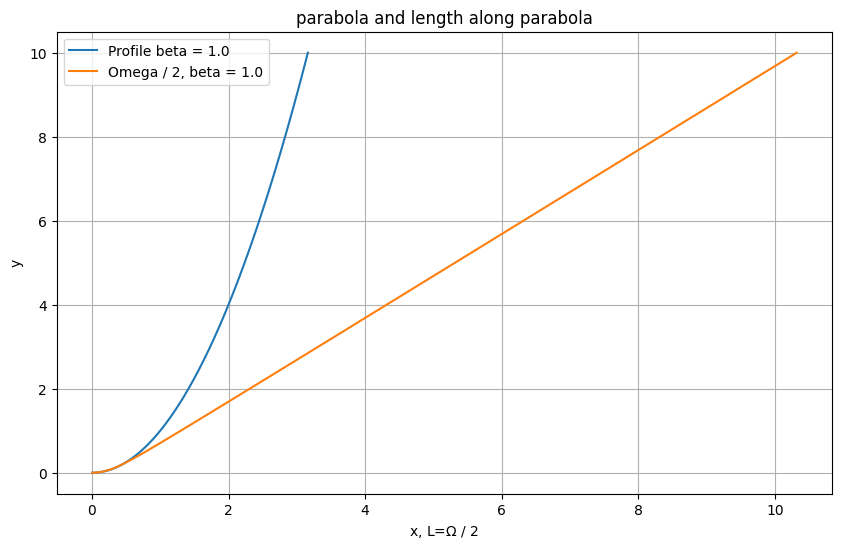

In [3]:
def Omega(y, beta):
    """Return length along parabola between 0 and y.
    
    Parameters
    ----------
    y: float or np.ndarray
        The depth above the bottom of the vertical parabola.
    beta: float
        Half-width of parabola at y=1.
    
    >>>y = 0.001
    >>>y1, y2 = 1000, 1100
    >>>print(f"For small y, like y = {y}, x must be about equal to Omega: {beta * np.sqrt(y):.6g} = {Omega(y, beta):.6g}")
    >>>print(f"For large y2 and y1, like {y2} and {y1}, y2-y1={y2 - y1:.6g} must be about equal to {Omega(y2, beta) - Omega(y1, beta):.6g}")
    >>>print(y, beta* np.sqrt(y), Omega(y, beta))
    >>>print(y2 - y1, beta* np.sqrt(y2) - beta * np.sqrt(y1), Omega(y2, beta) - Omega(y1, beta))
    For small y, like y = 0.001, x must be about equal to Omega: 0.0316228 = 0.0316019
    For large y2 and y1, like 1100 and 1000, y2-y1=100 must be about equal to 100
    0.001 0.03162277660168379 0.03160193355760483
    100 1.543471301870209 100.00000213017336
    """
    a = beta ** 2  /  4
    L = np.sqrt(y * (a + y)) + a * np.arctan(np.sqrt(y / (a + y)))
    return L

def ditch_profile(y, beta):
    return beta * np.sqrt(y)

y = np.logspace(-5, 1, 1000)
beta = 1.

fig, ax = plt.subplots(figsize=(10, 6))
ax.set(title="parabola and length along parabola", xlabel=r"x, L=$\Omega$ / 2", ylabel="y")

ax.plot(ditch_profile(y, beta), y, label=f"Profile beta = {beta}")
ax.plot(Omega(y, beta), y, label=f"Omega / 2, beta = {beta}")
ax.grid()
ax.legend()

fig.savefig(os.path.join(dirs.images, 'parabola_omega.png'))

plt.show()

# Toepassing in een eindige differentie model

Slootdiepte $y$

$$ y = \eta \sqrt{q}$$

De drainageweerstand $c$, wanneer opgelegd als wiskundige functie zonder naar de fysieke weerstand en het slootprofiel te kijken:
$$\frac 1 c =\frac{\sqrt{q}}{\gamma}$$

De coëfficiënt kan ook hier worden bepaald uit de referentiesituatie bij gemiddeld neerslagoverschot.
We kunnen nu de lek in het model formuleren op basis van de hoogte van de constante slootbodem $h_0$, zonder dat daarbij de slootdiepte $y$ nodig is

$$ q = \frac{\phi - h}{c} = \frac{\sqrt q}{\gamma}(\phi-h_0 - (h - h_0))$$

Dus, met slootdiepte $y=h-h_0 = \eta \sqrt q$ volgt na enige uitwerking

$$ q = \frac {\sqrt q} {\gamma + \eta} (\phi - h_0)$$

zodat

$$c = \frac{\gamma + \eta}{\sqrt{q}}$$

Hiermee hebben de het slootniveau geheel geëlimineerd van het model voor de situatie waarin we de drainageweerstand hebben opgelegd als mathematische functie $c = \frac{\gamma}{\sqrt{q}}$ en voor de slootdiepte geldt $y=\eta \sqrt{q}$.

# De algemene situatie waarin we wel $y=\eta \sqrt{q}$ handhaven maar $c$ een willekeurige functie is van de slootdiepte, zoals bijvoorbeeld een fysisch verband op basis van het slootprofiel.

We beginnen de afleiding starten op dezelfde manier als hiervoor

$$ q = \frac{\phi - h}{c_{dr}} = \frac 1 c_{dr} \, (\phi-h_0 - y)$$

Met dezelfde relatie $h=\eta \sqrt q$ volgt

$$ q = \frac{\phi - h_0}{c_{dr} + \frac \eta {\sqrt q}}$$

Zodat we kunnen overschakelijk van drainagepeil $h$ naar slootbodemhoogte $h$ door de drainageweerstand $c_{dr}$ te vervangen door

$$c=c_{dr} + \frac{\eta}{\sqrt{q}}$$


## De uittreeweerstand door radiale stroming (zie Huisman (1972))

De fysische drainageweerstand is de sum van de bijdrage door horizontale, door verticale en radiale stroming. De radiale weerstand is

$$ c_r = \frac{\Delta s}{q} = \frac 1 {\pi k}\ln \left(\frac D \Omega\right)$$

Uitgaande van de slootomtrek $\Omega_{y_0}$ in de referentiesituatie $c_N$ kan de drainageweerstand bij andere $\Omega$ direct worden bepaald

$$c_{dr} = c_N + \frac{L}{\pi k}\ln\left(\frac{\Omega_{y_0}}{\Omega_{y}}\right)$$


## Situatie met opgelegde wiskundige relatie voor de drainageweerstand

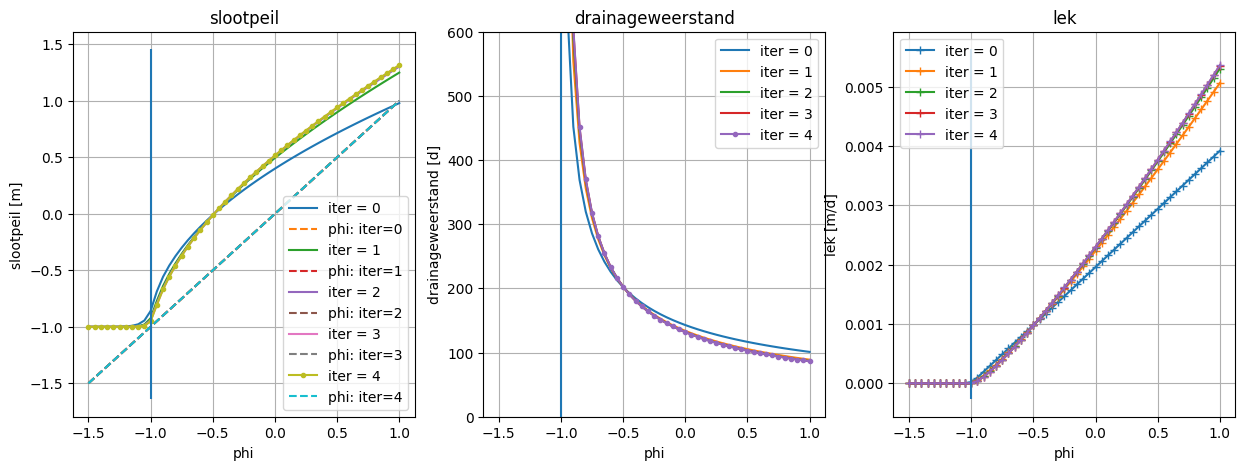

In [4]:
def keep_positive(x, delta=0.01):
    x = np.atleast_1d(x).astype(float)
    y = x.copy()
    mask = x < np.e * delta
    y[mask] = delta * np.exp(x[mask] / (np.e * delta))
    if len(y) == 1:
        y = y.ravel().item()
    return y

hN, h0, N, cN = 0., -1.0, 0.001, 200.
phiN = hN + N * cN
y = hN - h0
c= cN
eta = y / np.sqrt(N)
gamma = np.sqrt(N) * cN
q = N
phi = np.linspace(hN - 1.5, hN + 1, 51)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, sharex=True, figsize=( 15, 5))
ax1.set(title="slootpeil", xlabel='phi', ylabel="slootpeil [m]")
ax2.set(title="drainageweerstand", xlabel='phi', ylabel="drainageweerstand [d]")
ax3.set(title="lek", xlabel='phi', ylabel="lek [m/d]")
    
n = 5
for i in range(n):

    q = keep_positive(phi - h0) / (c + eta / np.sqrt(keep_positive(q)))
            
    c = gamma / np.sqrt(q)
    h = h0 + eta * np.sqrt(q)
    if i in range(n):
        marker = None if i != n - 1 else '.'
            
        ax1.plot(phi, h, marker=marker, label=f"iter = {i}")
        ax1.plot(phi, phi, '--', label=f'phi: iter={i}')
        ax2.plot(phi, c, marker=marker, label=f"iter = {i}")
        ax3.plot(phi, q, marker='+', label=f"iter = {i}")
        

for ax in [ax1, ax2, ax3]:        
    ax.vlines([h0], *ax.get_ylim())
    ax.grid()
    ax.legend()

ax2.set_ylim(0, 600)
plt.show()


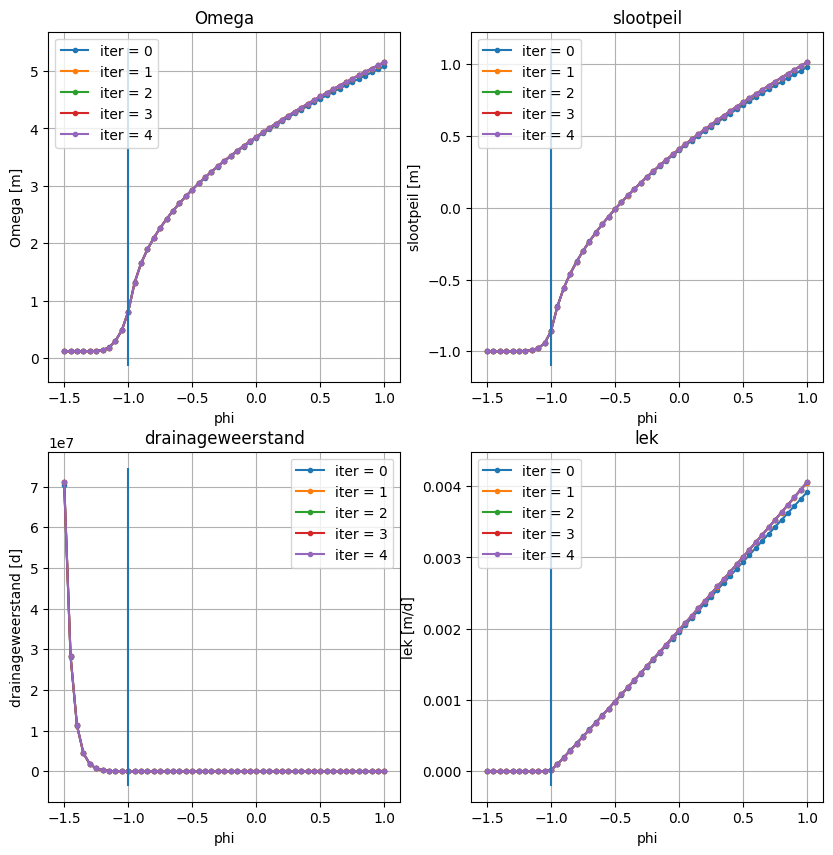

In [5]:
def Omega(beta, y, yhat=0.01):
    """Return contact length between ditch and water-table aquifer in cross section.
    
    Parameters
    ----------
    beta: coefficient, float
        Coefficient defining the with of the parabolic ditch profile
        from w(y) = 2 \beta np.sqrt(y)
    y: np.ndarray or float
        Ditch depth, h - h0.
    """
    y = np.atleast_1d(y).astype(float)
    L = np.zeros_like(y)
    mask = y > yhat
    # mask = y > 0
    L[mask] = np.sqrt(y[mask] * (beta ** 2 / 4 + y[mask])) + beta ** 2 / 4 * np.arctanh(np.sqrt(y[mask] / (beta ** 2 / 4 + y[mask])))
    lambda_ = 2 * yhat
    A = beta * np.sqrt(yhat) / np.exp(0.5)
    L[~mask] = A * np.exp(y[~mask] / lambda_)
    return 2 * L
                     
def c_dr(y, *, y0=None, cN=None, beta=None, k=None, L=None):
    """Return drainage resistance based on Omega.
    
    Parameters
    ----------
    D: float
        Thickness of water-table aquifer.
    omega: np.ndarray of float
        Wet contact length between ditch and aquifer in cross section.
    k: float
        Hydraulic conductivity. May use k=np.sqrt(kx * kz).
    L: float
        Distance between the ditches.
    """
    c = cN + np.log(Omega(beta, y0) / Omega(beta, y))
    return c


hN, h0, N, cN, beta = 0., -1.0, 0.001, 200., 1.0
phiN = hN + N * cN
y0 = hN - h0
k, L = 2., 100.

c= cN
eta = y / np.sqrt(N)
gamma = np.sqrt(N) * cN
q = N
phi = np.linspace(hN - 1.5, hN + 1, 51)
h=hN
y = h - h0

fig, axs = plt.subplots(2, 2, figsize=( 10, 10))
ax0, ax1, ax2, ax3 = axs.flatten()
ax0.set(title="Omega", xlabel='phi', ylabel="Omega [m]")
ax1.set(title="slootpeil", xlabel='phi', ylabel="slootpeil [m]")
ax2.set(title="drainageweerstand", xlabel='phi', ylabel="drainageweerstand [d]")
ax3.set(title="lek", xlabel='phi', ylabel="lek [m/d]")

n = 5
for i in range(n):
    cdr = c_dr(y, y0=y0, cN=cN, beta=beta, k=k, L=L)       
    q = keep_positive(phi - h0) / (cdr + eta / np.sqrt(keep_positive(q)))
    c = cdr + eta / np.sqrt(q)
    y = eta * np.sqrt(q)
    h = h0 + y
    if i in range(n):
        ax0.plot(phi, Omega(beta, y), marker=marker, label=f"iter = {i}")
        ax1.plot(phi, h, marker=marker, label=f"iter = {i}")
        ax2.plot(phi, c, marker=marker, label=f"iter = {i}")
        ax3.plot(phi, q, marker=marker, label=f"iter = {i}")

for ax in axs.ravel(): 
    ax.vlines([h0], *ax.get_ylim())
    ax.grid()
    ax.legend()
    
plt.show()


# Functie om Omega positief te houden als y < yhat

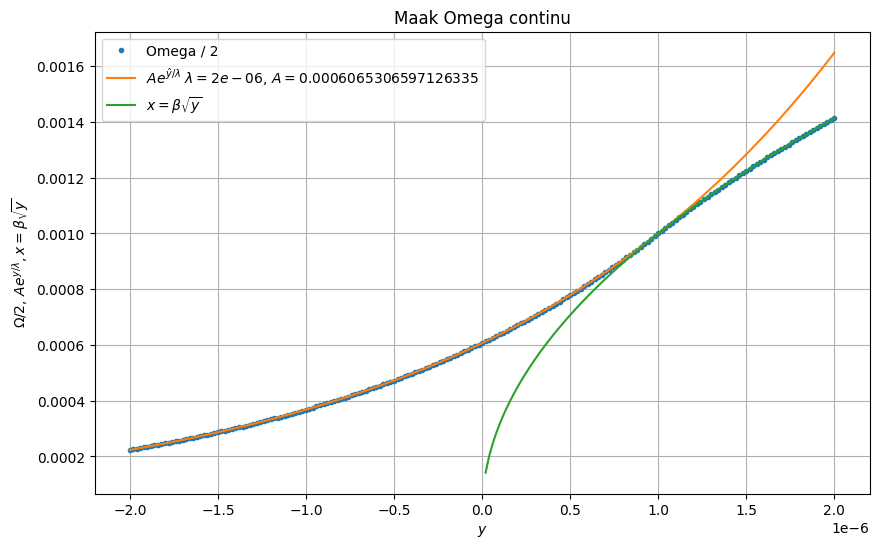

In [6]:
yhat = 0.000001
lambda_ = 2 * yhat
beta = 1.0
A = beta * np.sqrt(yhat) / np.exp(0.5)
y = np.linspace(-2 * yhat, 2 * yhat, 201)
fig, ax = plt.subplots(figsize=(10, 6))
ax.set(title="Maak Omega continu", xlabel=r"$y$", ylabel=r"$\Omega / 2,\, A e^{y / \lambda}, x=\beta \sqrt{y}$")
ax.plot(y, Omega(beta, y, yhat=yhat) / 2, '.', label="Omega / 2")
ax.plot(y, A * np.exp(y / lambda_), label=r"$A e^{\hat{y} / \lambda}$ " + rf"$\lambda={lambda_},\,A={A}$")
ax.plot(y[y > 0], beta * np.sqrt(y[y > 0]), label=r'$x = \beta \sqrt{y}$')
ax.grid()
ax.legend()
plt.show()

# Fun tie om lijn y=x positief te houden


We willen een snel aflopende lijne aansluiten op de functie $y=\phi$. De lijn moet continu zijn snel naar nul gaan voor $\phi < 0$. De voor de hand liggende functie is dan

$$ y = \delta e^{\frac{\phi - h_0}{\lambda}}$$

Waar $\delta$ een klein positief getal is, dimensie [L].

Beide aan elkaar knopen geeft

$$ \delta e^{\frac{\phi-h_0}{\lambda}} = \phi - h_0$$

De afgeleide aan beide zijden

$$
\frac \delta \lambda e^{\frac{\phi - h_0} \lambda} = 1
$$

Beide vergelijkingen op elkaar delen levert het punt $\phi_0$ op waar beide lijnen continu in elkaar overgaan

$$ \phi_0=\lambda $$

Dit ingevuld in vergelijking 1 levert

$$ \delta  =e^{-1} \lambda $$

Kiezen we $ \delta $, dan ligt $\lambda$ vast

$$ \lambda = \delta  e^1 \approx 2.72 \delta $$

Door beide vergelijkingen op het punt $phi - h_0 = \lambda = 2.72 \delta$ aan elkaar te knopen ontstaat een continue functie van $\phi$

$$ y = \phi - h_0, \,\,\,\rightarrow \,\,\, \phi - h_0 \ge \lambda = 2.72 \delta$$
$$ y = \delta e^{\frac{\phi - h_0} \lambda}\,\,\, \rightarrow\,\,\, \phi - h_0 \le \lambda$$



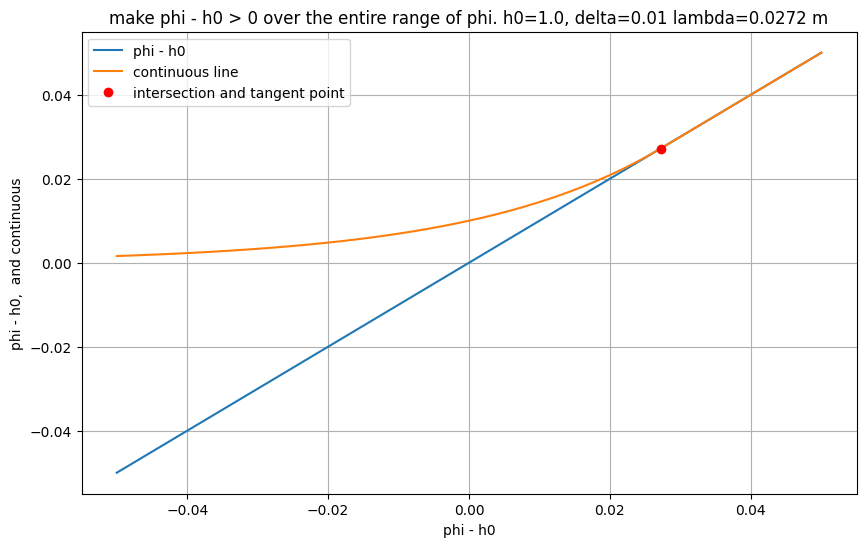

In [7]:
def yy(phi, delta, h0):
    phi = np.atleast_1d(phi)
    lam = np.exp(1) * delta
    mask = phi - h0 < lam
    y = phi - h0
    y[mask] = delta * np.exp(y[mask] / lam)
    if len(y) == 1:
        y = y.item()
    return y

phi, h0, delta = np.linspace(0.95, 1.05, 51), 1.0, 0.01
lam = np.exp(1) * delta
fig, ax = plt.subplots(figsize=(10, 6))
title = f"make phi - h0 > 0 over the entire range of phi. h0={h0}, delta={delta} lambda={lam:.3g} m"
ax.set(title=title, xlabel="phi - h0", ylabel="phi - h0,  and continuous")
ax.plot(phi - h0, phi - h0, label="phi - h0")
ax.plot(phi - h0, yy(phi, delta, h0), label="continuous line")
ax.plot(lam, yy(lam + h0, delta, h0), 'ro', label="intersection and tangent point")
ax.grid()
ax.legend()
plt.show()

# Vergelijking van de modellen berekend met Fdm3

## Vlakke doorsnede 1 laag.

No outer iterations needed.

===== Water balance of the entire model =====
Model grid = (1, 1, 200)

Sum over all nodal flows should be zero:
Total net in Q1     =          0 m3/d

Boundary components, these components should also add up zo zero:
Fixed flows         FQ   =           1.000 m3/d
Fixed heads         QFH  =           0.000 m3/d
GHB                Qghb =          -1.000 m3/d, flow from GHB cells.

Total water balance of this model
Q1 (internal)            =           0.000 m3/d, total internal flow
Q2 (boundaries)          =          -0.000 m3/d, total from boundaries
===== end of water balance =====

Non-linear options: ['DRN'], starting outer iterations:
iouter =    0, err =    0.42291 m, errBalance =       -0.8
iouter =    1, err =    0.32797 m, errBalance =     -1.273
iouter =    2, err =    0.34743 m, errBalance =    -1.9635
iouter =    3, err =    0.37379 m, errBalance =    -2.7586
iouter =    4, err =    0.37698 m, errBalance =    -3.4402
iouter =    5, err =    0.33

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

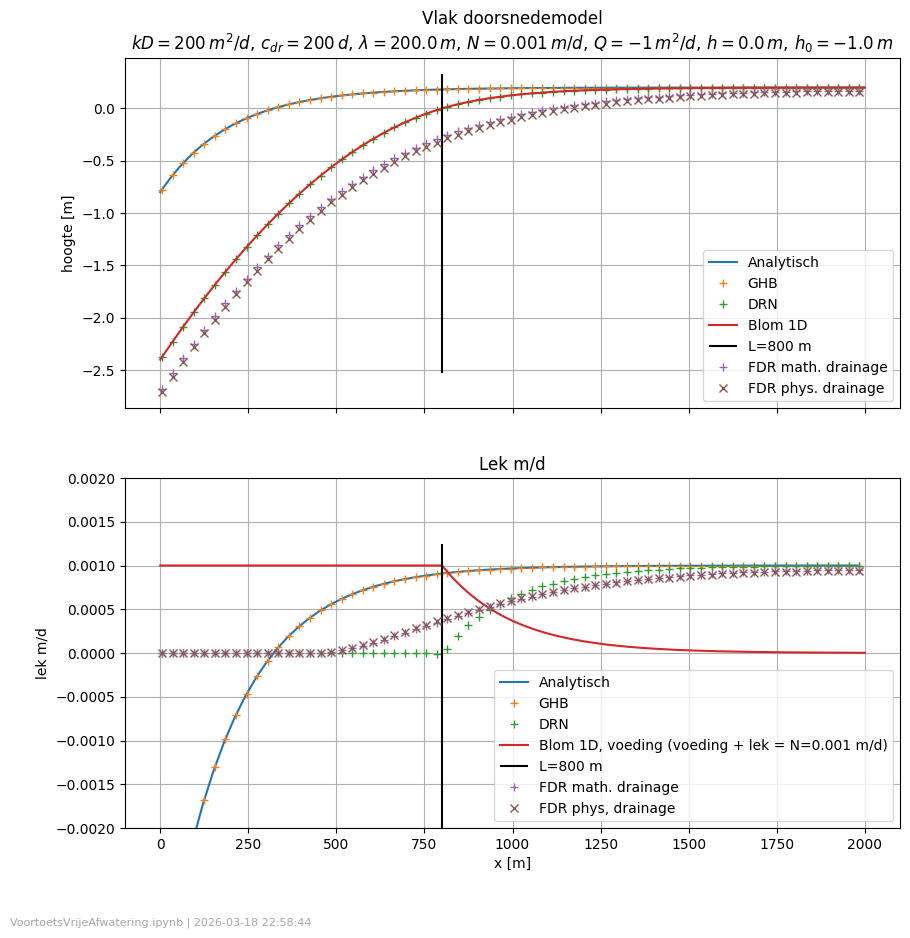

In [8]:
reload(wf)

# --- Basic parameters
k, D, cdr, N, h, h0, w, L = 10, 20, 200, 0.001, 0., -1.0, 1.0, 100.
kD = k * D
lambda_ = np.sqrt(kD * cdr)

# --- The grid
x = np.linspace(0, 2000., 201)
gr = Grid(x, [-0.5, 0.5], [0., -D], axial=False)

S = gr.const(0.001)

# --- Modflow5-like boundary array
IBOUND = gr.const(1)

# --- Initial head
HI = gr.const(h + N * cdr)

# -- Boundary conditions
FQ = gr.const(N) * gr.AREA
Q =  -0.5 * FQ.sum()
FQ[-1, 0, 0] +=Q

# --- Instantiate the model
mdl = Fdm3(gr=gr, K=gr.const(k), c=None, S=S, IBOUND=IBOUND, HI=HI, FQ=FQ)

# --- General head boundaries
GHB = np.zeros(gr.nx, dtype=Fdm3.dtype['ghb'])
GHB['Ig'], GHB['h'], GHB['C'] = gr.NOD[0, 0, :], h, gr.Area.ravel() / cdr

# --- Drains (same parameters as GHB)
DRN = GHB.copy()

# --- Free drainage parameters
FDR = np.zeros(gr.nx, dtype=Fdm3.dtype['fdr'])
FDR['Ig'], FDR['phi'], FDR['h'], FDR['h0'], FDR['N'] = gr.NOD[0, 0, :], h + N * cdr, h, h0, N

FDR1 = FDR.copy()
FDR2 = FDR.copy()

FDR2['w'], FDR2['L'] = w, L

# --- Analytic solution (Mazure)
phi = h + Q * np.sqrt(lambda_ / kD) * np.exp(-gr.x / lambda_) + N * cdr
dqdx = Q / lambda_ * np.exp(-x / lambda_)

# --- Simulate the model for each type of boundaries in turn
out_ghb = mdl.simulate(GHB=GHB)
out_drn = mdl.simulate(DRN=DRN)
out_fdr1 = mdl.simulate(FDR=FDR1)
out_fdr2 = mdl.simulate(FDR=FDR2)

# --- Show simulation results
fig,(ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 10))

# --- Set up axes
title = ("Vlak doorsnedemodel\n" + 
         rf"$kD={k * D}\,m^2/d,\,c_{{dr}}={cdr}\,d,\,\lambda={np.sqrt(k * D * cdr)}\,m,\,N={N}\,m/d,\,Q={Q:.3g}\,m^2/d,\,h={h}\,m,\,h_0={h0}\,m$"
)
ax1.set(title=title, ylabel='hoogte [m]')
ax2.set(title='Lek m/d', xlabel='x [m]', ylabel='lek m/d')
ax1.grid()
ax2.grid()

# --- Instantiate a Blom 1D model
Bl = wf.Blom1D(aqprops={'kD':k * D, 'c': cdr})

ax1.plot(gr.x, phi, label="Analytisch")
ax1.plot(gr.xm[::3], out_ghb['Phi'][-1, 0][::3], '+', label="GHB")
ax1.plot(gr.xm[::3], out_drn['Phi'][-1, 0][::3], '+', label="DRN")

ax1.plot(gr.x, N * cdr -Bl.dd(Q=-Q, x=gr.x, N=N), label="Blom 1D")

ax2.plot(gr.x[::3], dqdx[::3] + N, label="Analytisch") # dqdx is infiltratie, N heeft dus hetzelfde teken.

ax2.plot(gr.xm[::3], out_ghb['GHB']['q'][::3], '+', label="GHB")
ax2.plot(gr.xm[::3], out_drn['DRN']['q'][::3], '+', label="DRN")

ax2.plot(gr.x, Bl.q(Q=-Q, x=gr.x, N=N), label=f"Blom 1D, voeding (voeding + lek = N={N} m/d)")

L = Bl.getL(Q=Q, N=N)
ymin, ymax = ax1.get_ylim()
ax1.vlines([L], ymin=ymin, ymax=ymax, colors='k', label=f"L={L:.4g} m")
ymin, ymax = ax2.get_ylim()
ax2.vlines([L], ymin=ymin, ymax=ymax, colors='k', label=f"L={L:.4g} m")

ax2.set_ylim(-2 * N, 2 * N)
ax1.legend()
ax2.legend()

logo(fig, NOTEBOOK_NAME)
fig.savefig(os.path.join(dirs.images, 'example_fdm3_1D.png'))

# --- Plot numerieke resultaten
# --- Heads
ax1.plot(gr.xm[::3], out_fdr1['Phi'][-1, 0][::3], '+', label="FDR math. drainage")
ax1.plot(gr.xm[::3], out_fdr2['Phi'][-1, 0][::3], 'x', label="FDR phys. drainage")
# --- Flows
ax2.plot(gr.xm[::3], out_fdr1['FDR']['q'][::3], '+',   label="FDR math. drainage")
ax2.plot(gr.xm[::3], out_fdr2['FDR']['q'][::3], 'x',   label="FDR phys, drainage")

ax1.legend()
ax2.legend()

fig.savefig(os.path.join(dirs.images, 'example_fdm3_1D+FDR.png'))

plt.plot


## Axiaal symmetrische doorsnede, GHB en met DRN

axial==True so that y coordinates and ky are ignored
            and x stands for r, so that all x coordinates must be >= 0.
No outer iterations needed.

===== Water balance of the entire model =====
Model grid = (1, 1, 200)

Sum over all nodal flows should be zero:
Total net in Q1     = -8.4583e-11 m3/d

Boundary components, these components should also add up zo zero:
Fixed flows         FQ   =        9424.778 m3/d
Fixed heads         QFH  =           0.000 m3/d
GHB                Qghb =       -9424.778 m3/d, flow from GHB cells.

Total water balance of this model
Q1 (internal)            =          -0.000 m3/d, total internal flow
Q2 (boundaries)          =           0.000 m3/d, total from boundaries
===== end of water balance =====

Non-linear options: ['DRN'], starting outer iterations:
iouter =    0, err =     7.4872 m, errBalance =    -2513.3
iouter =    1, err =     1.8087 m, errBalance =    -4637.3
iouter =    2, err =     1.0486 m, errBalance =    -7153.9
iouter =    3, err =

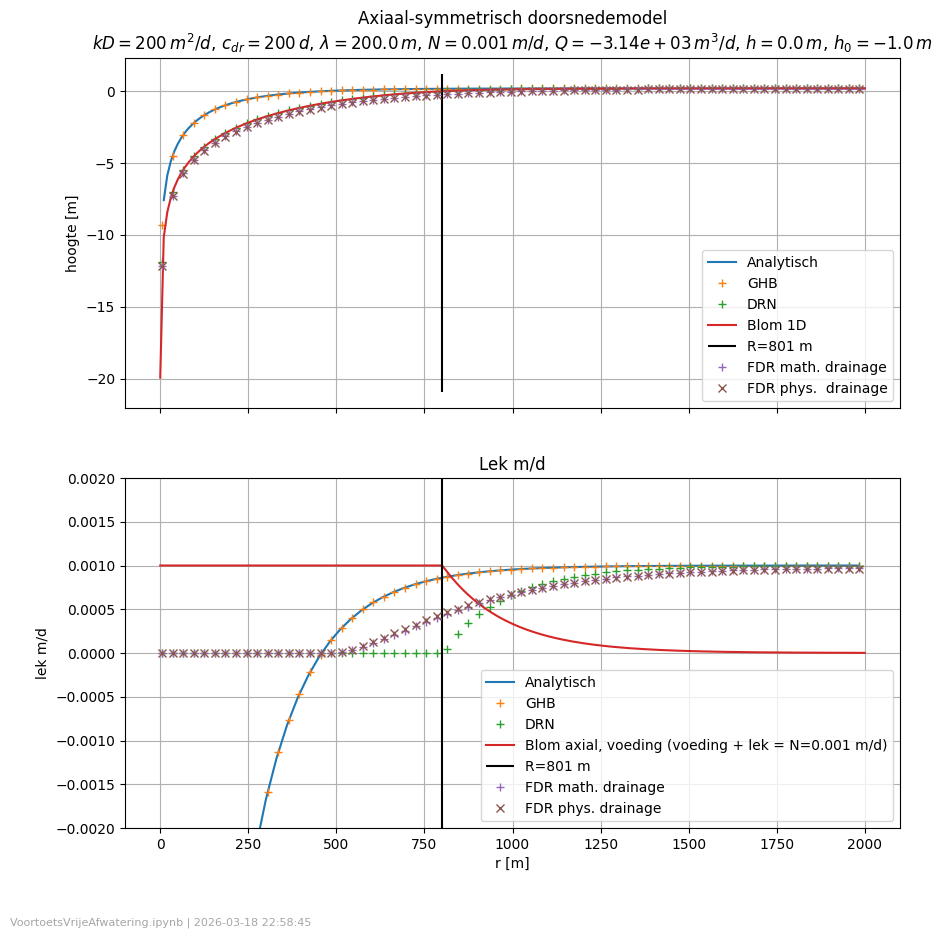

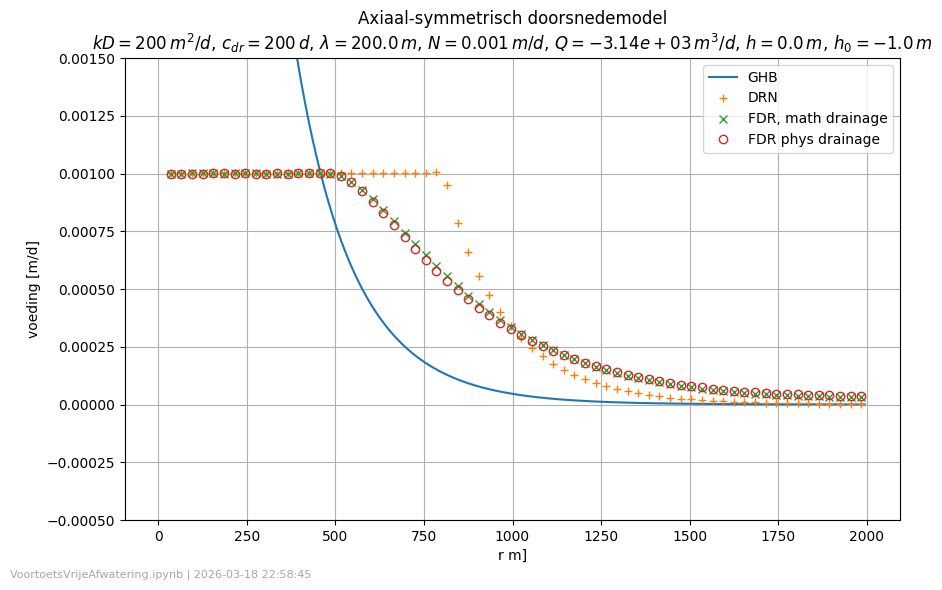

In [9]:
# --- Basic model parameters
k, D, cdr, N, h, h0, w, L = 10, 20, 200, 0.001, 0., -1.0, 1.0, 100.
lambda_ = np.sqrt(k * D * cdr)

# --- The grid (axially symmetric)
r = np.linspace(0, 2000., 201)
gr = Grid(r, [-0.5, 0.5], [0., -D], axial=True)

# --- Full array parameters
S = gr.const(0.001)

# --- Modflow5-like boundary array
IBOUND = gr.const(1)

# --- Initial heads
HI = gr.const(h + N * cdr)

# --- Boundary conditions
FQ = gr.const(N) * gr.AREA
Q =  -0.25 * FQ.sum()
FQ[-1, 0, 0] +=Q

# --- Instantiate the fdm model
mdl = Fdm3(gr=gr, K=gr.const(k), c=None, S=S, IBOUND=IBOUND, HI=HI, FQ=FQ)

# --- Boundary conditions of various type
GHB = np.zeros(gr.nx, dtype=Fdm3.dtype['ghb'])
GHB['Ig'], GHB['h'], GHB['C'] = gr.NOD[0, 0, :], h, gr.Area.ravel() / cdr

DRN = GHB.copy()

# --- Free drainage
FDR = np.zeros(gr.nx, dtype=Fdm3.dtype['fdr'])
FDR['Ig'], FDR['phi'], FDR['h'], FDR['h0'], FDR['N'] = gr.NOD[0, 0, :], h + N * cdr, h, h0, N

FDR1 = FDR.copy()
FDR2 = FDR.copy()

FDR2['w'], FDR2['L'] = w, L

# --- Simulate the model on turn for each boundary type
out_ghb = mdl.simulate(GHB=GHB)
out_drn = mdl.simulate(DRN=DRN)
out_fdr1 = mdl.simulate(FDR=FDR1)
out_fdr2 = mdl.simulate(FDR=FDR2)

# --- Set up the figure and axes
fig,(ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 10))

title = ("Axiaal-symmetrisch doorsnedemodel\n" + 
         rf"$kD={k * D}\,m^2/d,\,c_{{dr}}={cdr}\,d,\,\lambda={np.sqrt(k * D * cdr)}\,m,\,N={N}\,m/d,\,Q={Q:.3g}\,m^3/d,\,h={h}\,m,\,h_0={h0}\,m$"
)
ax1.set(title=title, ylabel='hoogte [m]')
ax2.set(title='Lek m/d', xlabel='r [m]', ylabel='lek m/d')
ax1.grid()
ax2.grid()

# --- Instantiate axially symmetric Blom model
Bl = wf.wBlom(aqprops={'kD':k * D, 'c': cdr})
lambda_ = Bl.aq['lambda']

# --- Analytic solution according to De Glee
phi = h + Q / (2 * np.pi * kD) * K0(gr.x / lambda_) + N * cdr
q = (phi - h) / cdr

# --- Plot results
# --- Heads
ax1.plot(gr.x, phi, label="Analytisch")
ax1.plot(gr.xm[::3], out_ghb['Phi'][-1, 0][::3], '+', label="GHB")
ax1.plot(gr.xm[::3], out_drn['Phi'][-1, 0][::3], '+', label="DRN")
ax1.plot(gr.x, N * cdr -Bl.dd(Q=-Q, x=gr.x, N=N), label="Blom 1D")

# --- Flows
ax2.plot(gr.x[::3], q[::3], label="Analytisch") # q is infiltratie, N ook dus hetzelfde teken.
ax2.plot(gr.xm[::3], out_ghb['GHB']['q'][::3], '+', label="GHB")
ax2.plot(gr.xm[::3], out_drn['DRN']['q'][::3], '+', label="DRN")
ax2.plot(gr.x, Bl.q(Q=-Q, x=gr.x, N=N), label=f"Blom axial, voeding (voeding + lek = N={N} m/d)")

# --- Extra info on the plot (Blom boundary)
R = Bl.getR(R=1.0, Q=Q, N=N)
ymin, ymax = ax1.get_ylim()
ax1.vlines([R], ymin=ymin, ymax=ymax, colors='k', label=f"R={R:.4g} m")
ymin, ymax = ax2.get_ylim()
ax2.vlines([R], ymin=ymin, ymax=ymax, colors='k', label=f"R={R:.4g} m")

ax2.set_ylim(-2 * N, 2 * N)
ax1.legend()
ax2.legend()

logo(fig, NOTEBOOK_NAME)
fig.savefig(os.path.join(dirs.images, 'example_fdm3_axsym.png'))

# --- Plot the heads of the FDM model for each type of boundary
ax1.plot(gr.xm[::3], out_fdr1['Phi'][-1, 0][::3], '+',  label="FDR math. drainage")
ax1.plot(gr.xm[::3], out_fdr2['Phi'][-1, 0][::3], 'x', label="FDR phys.  drainage")

# --- Plot the flows of the FDM model for each type of boundary
ax2.plot(gr.xm[::3], out_fdr1['FDR']['q'][::3], '+',    label="FDR math. drainage")
ax2.plot(gr.xm[::3], out_fdr2['FDR']['q'][::3], 'x',   label="FDR phys. drainage")

ax1.legend()
ax2.legend()

fig.savefig(os.path.join(dirs.images, 'example_fdm3_axsym+FDR.png'))

plt.plot

fig, ax3 = plt.subplots(figsize=(10, 6))
title = ("Axiaal-symmetrisch doorsnedemodel\n" + 
         rf"$kD={k * D}\,m^2/d,\,c_{{dr}}={cdr}\,d,\,\lambda={np.sqrt(k * D * cdr)}\,m,\,N={N}\,m/d,\,Q={Q:.3g}\,m^3/d,\,h={h}\,m,\,h_0={h0}\,m$"
)
ax3.grid()

ax3.set(title=title, xlabel='r m]', ylabel='voeding [m/d]')
ax3.plot(gr.xm[1:], (out_ghb[ 'Q'][0] / gr.Area).ravel()[1:], '-',   label="GHB")
ax3.plot(gr.xm[::3], (out_drn[ 'Q'][0] / gr.Area).ravel()[::3], '+', label="DRN")
ax3.plot(gr.xm[::3], (out_fdr1[ 'Q'][0] / gr.Area).ravel()[::3], 'x', label="FDR, math drainage")
ax3.plot(gr.xm[::3], (out_fdr2['Q'][0] / gr.Area).ravel()[::3], 'o', mfc='none', label="FDR phys drainage")
ax3.set_ylim(-0.0005, 0.0015)
ax3.legend()

logo(fig, NOTEBOOK_NAME)
fig.savefig(os.path.join(dirs.images, 'example_fdm3_axsym_rch.png'))


# Vrije afwatering zoals dat in Modflow kan.

Eerder was afgeleid op basis van $y = \eta \sqrt{q}$ en $\frac{1}{c\_{dr}}=\gamma \sqrt{q}$ dat

$$q = \frac{(\phi - h_0)^2}{(\gamma + \eta)^2} = \frac{\phi-h_0}{(\gamma + \eta)^2}(\phi=h_0)=C(\phi-h_0)$$

Dus dat bij gebruik van de bodemhoogte $h_0$ in plaats van het waterpeil $h$ als drainagebasis moet de conductantie evenredig zijn met de grondwaterstand $\phi$ boven de hoogte van de slootbodem $h_0$.

Om dit verband tussen $C$ en $\phi$ te modelleren door het stapelen van drains binnen een rekencel met elke drain zijn eigen conductancie en drainniveau krijg je

$$ q=\sum_i^n C_i (\phi[\phi > h_i] - h_i) = C (\phi - h_0)$$

Voor $n$ gelijke stapjes met elk eenzelfde conductantie $\Delta C$, zodat de conductantie bij benaderng lineair toeneemt met $\phi$ geldt

$$\Delta C ( n \phi - \sum_{i=0}^n h_i) = C(\phi - h_0) $$
Beide zijden delen door $n$ levert

$$\Delta C (\phi - \overline{h_i}) = \frac{C}{n}(\phi - h_0)$$

zodat

$$\Delta C = \frac C n \left(\frac{\phi-h_0}{\phi-\overline{h_i}} \right)$$

We kunnen dus het gewenste verloop verkrijgen door stapelen van $n$ drains in een en dezelfde cel, door alle dezelfde conductantie te geven gelijk aan $\Delta C$ hierboven. 

# Modflow: modellering vrije drainage met meerdere drainniveaus

Berekening van de conductantie en de afvoer.

[]

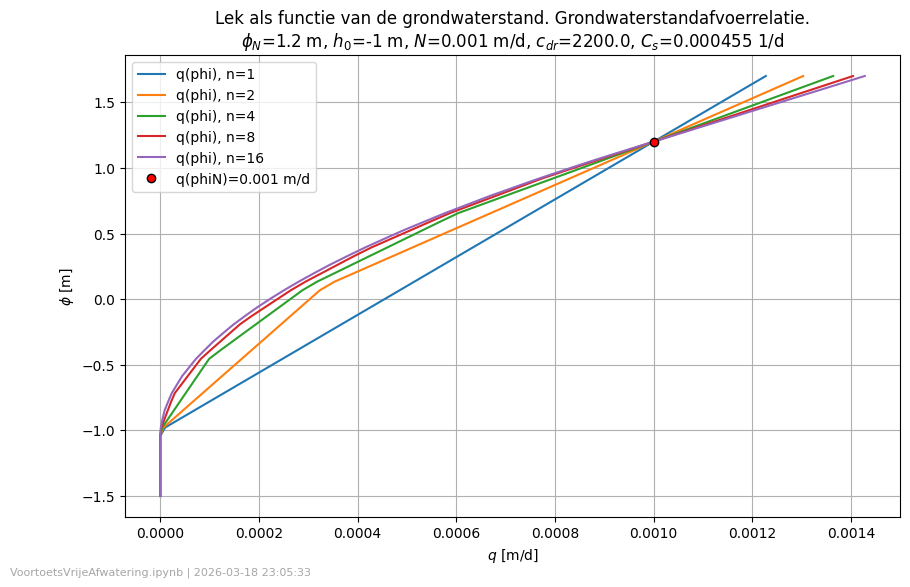

In [15]:
h0 = -1   # --- Surace water bottom elevation
N = 0.001 # --- Recharge (precipitation surplus)

# --- Head above water bottom given recharge surplus and leakage resistance
# --- Reference water level
phiN = h + N * cdr

# --- Leakage resistance (drainage resistance) [d]
cdr = (phiN - h0) / N

# --- Specific conductance [1/d]
Cs = 1 / cdr


class DRNn:
    def __init__(self, h0, phiN, Cs):
        """Class to generate conducance series to simulate free drainage.
                        
        Parameters
        ----------
        h0: float
            water bottom elevation.
        phiN: float
            surface water reference level (at N)
        Cs: float | np.ndarray
            Specific conductance at surface-water reference level.
        n: int
            number of drain levels between h0 and phiN (phiN not included)
        """
        self.h0 = h0
        self.phiN = phiN
        self.Cs = Cs

    def get_ch(self, n=6):
        self.n = n
        hdrn =np.linspace(self.h0, self.phiN, self.n + 1)[:-1]
        DeltaC = self.Cs / n * (self.phiN - self.h0) / (self.phiN - np.mean(hdrn))
        return DeltaC, hdrn
    
    def q(self, phi, n=6):
        """Return drain flux for surface water level at phi.
    
        Parameters
        ----------
        phi: float | np.ndarray
            surface water level for which drainage is computed.
        """
        DeltaC, hdrn = self.get_ch(n=n)
        q_ = np.zeros_like(phi)
        for hi in hdrn:
            q_[phi > hi] += DeltaC * (phi[phi > hi] - hi)        
        return q_
    
    def cond(self, phi, n=None):
        """Return total conductance at surface water levels phi.
        
        Parameters
        ----------
        phi: float
            Current surface water level.
        n: int
            Number of drainage levels.
        """
        DeltaC, hdrn = self.get_ch(n=n)
        cond_ = np.zeros_like(phi)
        for hi in hdrn:
            cond_[phi > hi] += DeltaC
        return cond_


phi = np.linspace(h0 -0.5, phiN + 0.5, 50)

drns = DRNn(h0=h0, phiN=phiN, Cs=Cs)

fig, ax = plt.subplots(figsize=(10, 6))
ax.set(title="Lek als functie van de grondwaterstand. Grondwaterstandafvoerrelatie.\n"
       + fr"$\phi_N$={phiN} m, $h_0$={h0} m, $N$={N} m/d, $c_{{dr}}$={cdr}, $C_s$={Cs:.3g} 1/d",
       xlabel=r"$q$ [m/d]",
       ylabel=r"$\phi$ [m]"
       )

for n in [1, 2, 4, 8, 16]:
    q = drns.q(phi, n=n)
    ax.plot(q, phi, '-', label=f"q(phi), n={n}")

ax.plot(N, phiN, 'o', mec='k', mfc='r', label=f"q(phiN)={N} m/d")

ax.grid()
ax.legend()
logo(fig, NOTEBOOK_NAME)
fig.savefig(os.path.join(dirs.images, "lek_vs_phi_drn1.png"))
plt.plot()

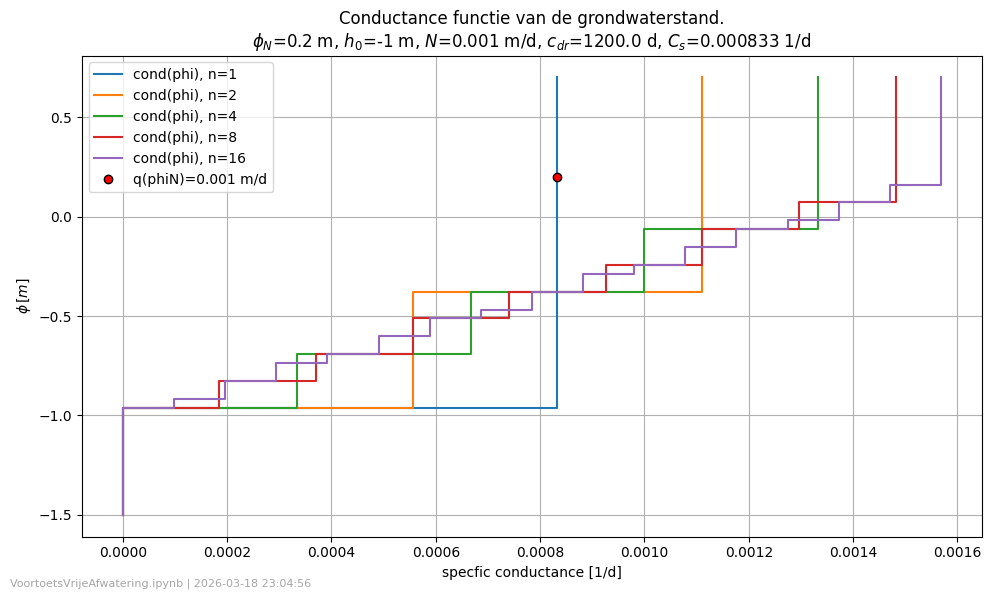

In [14]:
# %matplotlib Widget

fig, ax = plt.subplots(figsize=(10, 6))
ax.set(title="Conductance functie van de grondwaterstand.\n" +
       fr"$\phi_N$={phiN} m, $h_0$={h0} m, $N$={N} m/d, $c_{{dr}}$={cdr} d, $C_s$={Cs:.3g} 1/d", xlabel="specfic conductance [1/d]", ylabel=r"$\phi\,[m]$")

drns = DRNn(h0, phiN, Cs)

for n in [1, 2, 4, 8, 16]:
    cond = drns.cond(phi=phi, n=n)
    ax.step(cond, phi, '-', label=f"cond(phi), n={n}")

ax.plot(Cs, phiN, 'o', mec='k', mfc='r', label=f"q(phiN)={N} m/d")
ax.grid()
ax.legend()

fig.tight_layout()
logo(fig, NOTEBOOK_NAME)
fig.savefig(os.path.join(dirs.images, "condd_vs_phi_drn2.png"))
plt.show()

# Fdm3. Vlak doorsnedemodel, alle methodes

No outer iterations needed.

===== Water balance of the entire model =====
Model grid = (1, 1, 200)

Sum over all nodal flows should be zero:
Total net in Q1     =          0 m3/d

Boundary components, these components should also add up zo zero:
Fixed flows         FQ   =           1.000 m3/d
Fixed heads         QFH  =           0.000 m3/d
GHB                Qghb =          -1.000 m3/d, flow from GHB cells.

Total water balance of this model
Q1 (internal)            =           0.000 m3/d, total internal flow
Q2 (boundaries)          =          -0.000 m3/d, total from boundaries
===== end of water balance =====

Non-linear options: ['DRN'], starting outer iterations:
iouter =    0, err =    0.42291 m, errBalance =       -0.8
iouter =    1, err =    0.32797 m, errBalance =     -1.273
iouter =    2, err =    0.34743 m, errBalance =    -1.9635
iouter =    3, err =    0.37379 m, errBalance =    -2.7586
iouter =    4, err =    0.37698 m, errBalance =    -3.4402
iouter =    5, err =    0.33

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

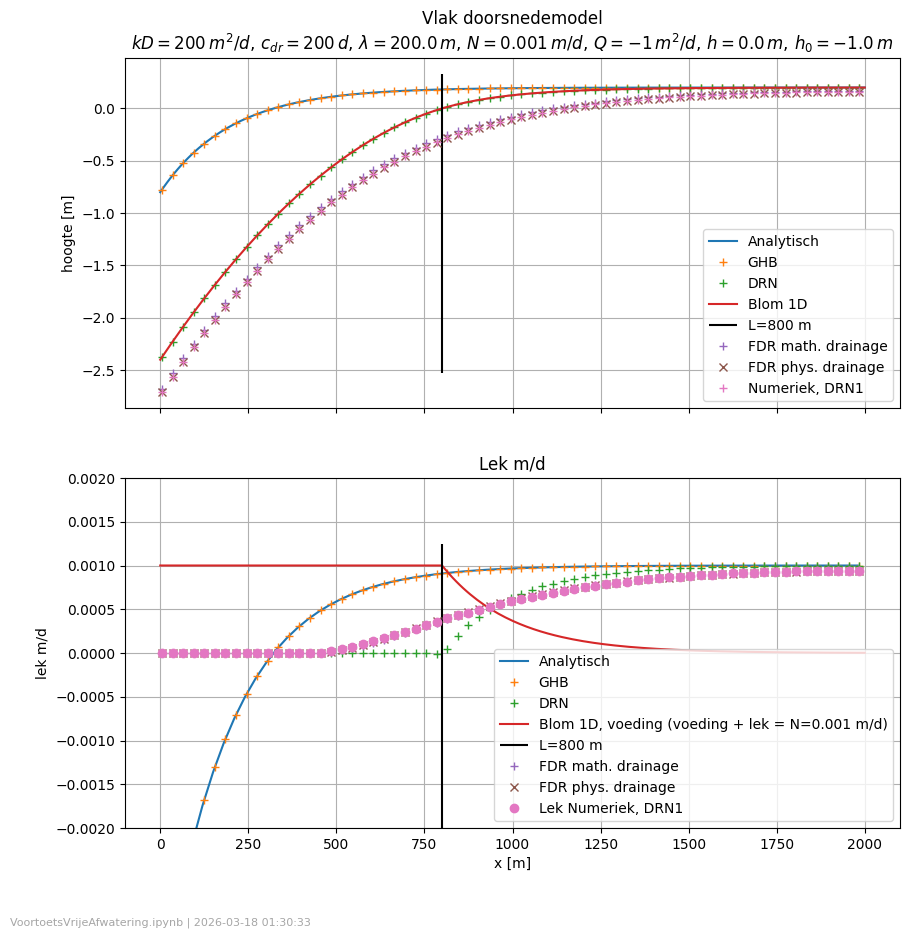

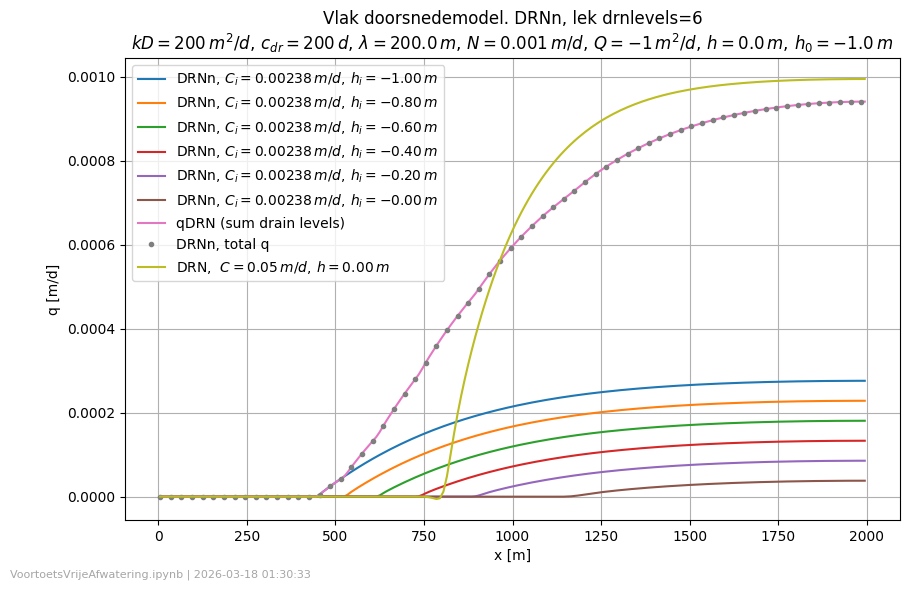

In [ ]:
k, D, cdr, N, h, h0, w, L = 10, 20, 200, 0.001, 0., -1.0, 1.0, 100.
phiN = h + N * cdr
lambda_ = np.sqrt(k * D * cdr)

x = np.linspace(0, 2000., 201)
gr = Grid(x, [-0.5, 0.5], [0., -D], axial=False)

S = gr.const(0.001)
IBOUND = gr.const(1)
HI = gr.const(h + N * cdr)
FQ = gr.const(N) * gr.AREA
Q =  -0.5 * FQ.sum()
FQ[-1, 0, 0] += Q

mdl = Fdm3(gr=gr, K=gr.const(k), c=None, S=S, IBOUND=IBOUND, HI=HI, FQ=FQ)

GHB = np.zeros(gr.nx, dtype=Fdm3.dtype['ghb'])
GHB['Ig'], GHB['h'], GHB['C'] = gr.NOD[0, 0, :], h, gr.Area.ravel() / cdr
DRN = GHB.copy()

# Mupltiple drains in cells to simulate a conductance depending on the head

drnlevels = 6
hdr = np.linspace(h0, phiN, drnlevels + 1)[:-1]
c = (phiN - h0) / N
C = 1 / c * (phiN - h0) / (phiN - np.mean(hdr)) / drnlevels
Ig = gr.NOD[0].flatten()
DRNn = np.zeros(drnlevels * gr.nx, dtype=Fdm3.dtype['drn'])
for i, hi in enumerate(hdr):
    i1, i2 = i * len(Ig), (i+1) * len(Ig)  
    DRNn['Ig'][i1:i2] = Ig
    DRNn['h' ][i1:i2] = hi
    DRNn['C' ][i1:i2] = gr.Area.flatten() * C

FDR = np.zeros(gr.nx, dtype=Fdm3.dtype['fdr'])
FDR['Ig'], FDR['phi'], FDR['h'], FDR['h0'], FDR['N'] = gr.NOD[0, 0, :], h + N * cdr, h, h0, N

FDR1 = FDR.copy()
FDR2 = FDR.copy()
FDR2['w'], FDR2['L'] = w, L

out_ghb = mdl.simulate(GHB=GHB)
out_drn = mdl.simulate(DRN=DRN)
out_fdr1 = mdl.simulate(FDR=FDR1)
out_fdr2 = mdl.simulate(FDR=FDR2)
out_drn1 = mdl.simulate(DRN=DRNn)

fig,(ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 10))

title = ("Vlak doorsnedemodel\n" + 
         rf"$kD={k * D}\,m^2/d,\,c_{{dr}}={cdr}\,d,\,\lambda={np.sqrt(k * D * cdr)}\,m,\,N={N}\,m/d,\,Q={Q:.3g}\,m^2/d,\,h={h}\,m,\,h_0={h0}\,m$"
)
ax1.set(title=title, ylabel='hoogte [m]')
ax2.set(title='Lek m/d', xlabel='x [m]', ylabel='lek m/d')
ax1.grid()
ax2.grid()

phi = h + Q * np.sqrt(lambda_ / kD) * np.exp(-gr.x / lambda_) + N * cdr
dqdx = Q / lambda_ * np.exp(-x / lambda_)

Bl = wf.Blom1D(aqprops={'kD':k * D, 'c': cdr})

ax1.plot(gr.x, phi, label="Analytisch")
ax1.plot(gr.xm[::3], out_ghb['Phi'][-1, 0][::3], '+', label="GHB")
ax1.plot(gr.xm[::3], out_drn['Phi'][-1, 0][::3], '+', label="DRN")
ax1.plot(gr.x, N * cdr -Bl.dd(Q=-Q, x=gr.x, N=N), label="Blom 1D")

ax2.plot(gr.x[::3], dqdx[::3] + N, label="Analytisch") # dqdx is infiltratie, N ook dus hetzelfde teken.
ax2.plot(gr.xm[::3], out_ghb['GHB']['q'][::3], '+', label="GHB")
ax2.plot(gr.xm[::3], out_drn['DRN']['q'][::3], '+', label="DRN")
ax2.plot(gr.x, Bl.q(Q=-Q, x=gr.x, N=N), label=f"Blom 1D, voeding (voeding + lek = N={N} m/d)")

L = Bl.getL(Q=Q, N=N)
ymin, ymax = ax1.get_ylim()
ax1.vlines([L], ymin=ymin, ymax=ymax, colors='k', label=f"L={L:.4g} m")
ymin, ymax = ax2.get_ylim()
ax2.vlines([L], ymin=ymin, ymax=ymax, colors='k', label=f"L={L:.4g} m")

ax2.set_ylim(-2 * N, 2 * N)
ax1.legend()
ax2.legend(loc='lower right')

fig.savefig(os.path.join(dirs.images, 'example_fdm3_1D.png'))

ax1.plot(gr.xm[::3], out_fdr1['Phi'][-1, 0][::3], '+', label="FDR math. drainage")
ax1.plot(gr.xm[::3], out_fdr2['Phi'][-1, 0][::3], 'x', label="FDR phys. drainage")
ax2.plot(gr.xm[::3], out_fdr1['FDR']['q'][::3], '+',   label="FDR math. drainage")
ax2.plot(gr.xm[::3], out_fdr2['FDR']['q'][::3], 'x',   label="FDR phys. drainage")

ax1.legend()
ax2.legend(loc="lower right")

fig.savefig(os.path.join(dirs.images, 'example_fdm3_1D+FDR.png'))

ax1.plot(gr.xm[::3], out_drn1['Phi'][-1, 0][::3], '+', label="Numeriek, DRN1")

qdrn1 = np.zeros(gr.nx)
np.add.at(qdrn1, out_drn1['DRN']['Ig'], out_drn1['DRN']['q'])
ax2.plot(gr.xm[::3], qdrn1[::3], 'o', label="Lek Numeriek, DRN1")
ax1.legend()
ax2.legend(loc='lower right')

logo(fig, NOTEBOOK_NAME)
fig.savefig(os.path.join(dirs.images, 'example_fdm3_1D+FDR+DRN1.png'))

# --- Drain discharge
fig, ax = plt.subplots(figsize=(10, 6))
ax.set(title=f"Vlak doorsnedemodel. DRNn, lek drnlevels={drnlevels}\n" +
       rf"$kD={k * D}\,m^2/d,\,c_{{dr}}={cdr}\,d,\,\lambda={np.sqrt(k * D * cdr)}\,m,\,N={N}\,m/d,\,Q={Q:.3g}\,m^2/d,\,h={h}\,m,\,h_0={h0}\,m$",
       xlabel="x [m]", ylabel="q [m/d]")
Ig = gr.NOD[0].flatten()
qtot = np.zeros(len(Ig), dtype=float)
drn1 = out_drn1['DRN']
for i1 in np.arange(0, len(drn1), len(Ig)):
    i2 = i1+ len(Ig)
    ax.plot(gr.xm, drn1['q'][i1:i2], label=fr"DRNn, $C_i={drn1['C'][i1:i2].mean():.3g}\,m/d,\,h_i={drn1['h'][i1:i2].mean():.2f}\,m$")
    qtot += drn1['q'][i1:i2]
ax.plot(gr.xm, qtot, label="qDRN (sum drain levels)")
ax.plot(gr.xm[::3], qdrn1[::3], '.', label="DRNn, total q")
ax.plot(gr.xm, out_drn['DRN']['q'], label=fr"DRN,  $C={out_drn['DRN']['C'].mean():.3g}\,m/d,\,h={out_drn['DRN']['h'].mean():.2f}\,m$")
ax.grid()
ax.legend(loc="upper left")

logo(fig, NOTEBOOK_NAME)
fig.savefig(os.path.join(dirs.images, "example_fdm3_1D_DRNn_leakage.png"))

plt.plot


# Axiaal-symmetrische doorsnede, alle methoden

axial==True so that y coordinates and ky are ignored
            and x stands for r, so that all x coordinates must be >= 0.
No outer iterations needed.

===== Water balance of the entire model =====
Model grid = (1, 1, 200)

Sum over all nodal flows should be zero:
Total net in Q1     = -3.0695e-11 m3/d

Boundary components, these components should also add up zo zero:
Fixed flows         FQ   =       11780.972 m3/d
Fixed heads         QFH  =           0.000 m3/d
GHB                Qghb =      -11780.972 m3/d, flow from GHB cells.

Total water balance of this model
Q1 (internal)            =          -0.000 m3/d, total internal flow
Q2 (boundaries)          =           0.000 m3/d, total from boundaries
===== end of water balance =====

Non-linear options: ['DRN'], starting outer iterations:
iouter =    0, err =     1.8718 m, errBalance =    -628.32
iouter =    1, err =    0.40277 m, errBalance =    -962.53
iouter =    2, err =    0.20339 m, errBalance =    -1174.8
iouter =    3, err =

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

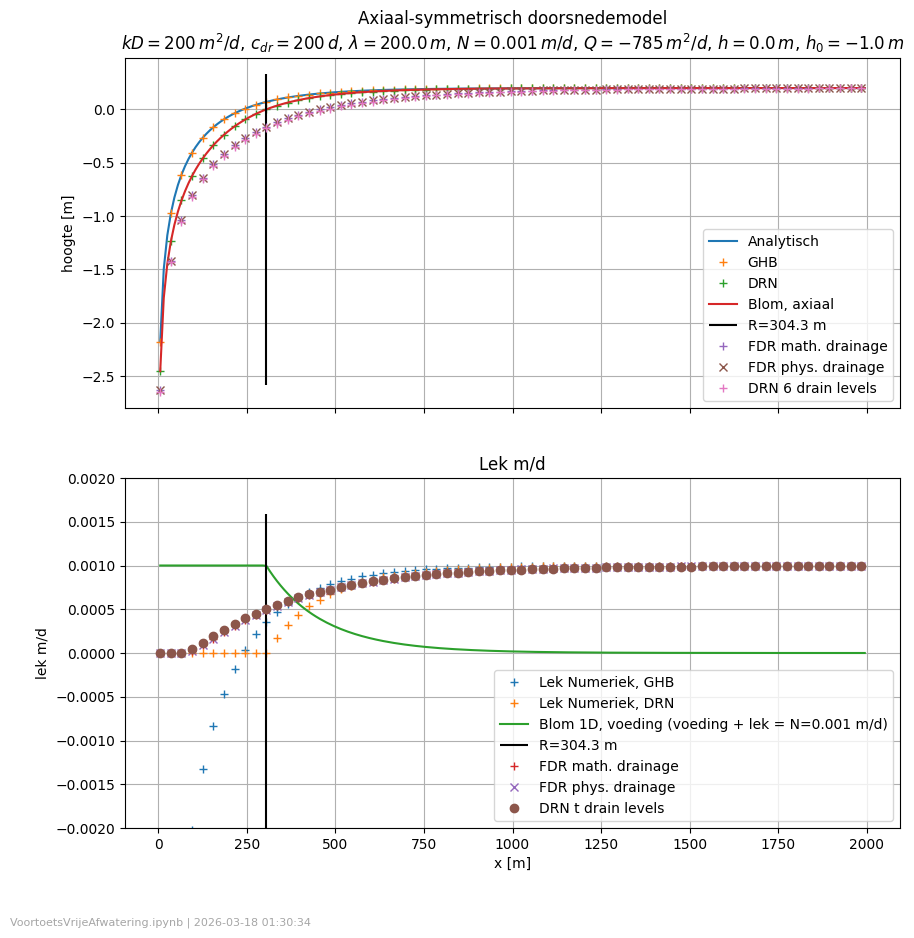

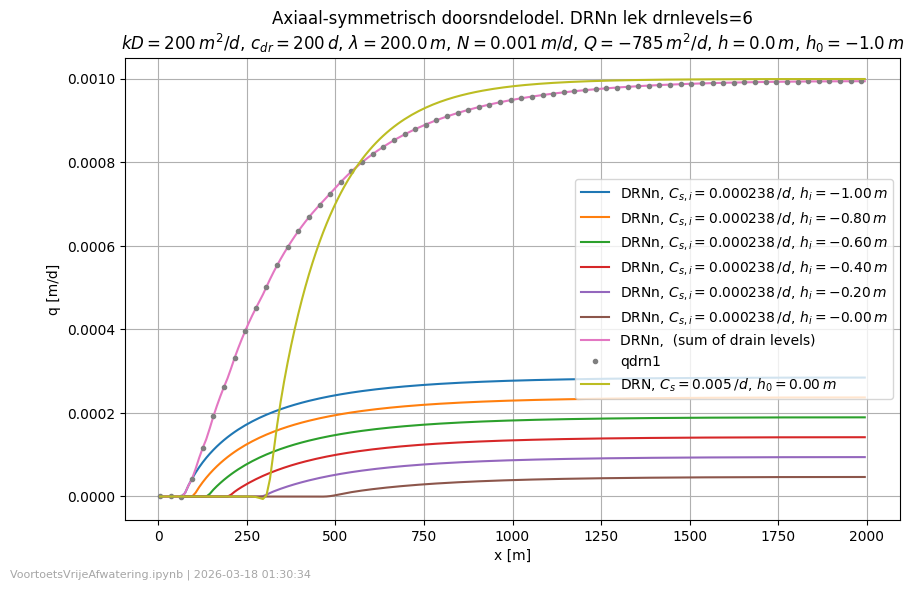

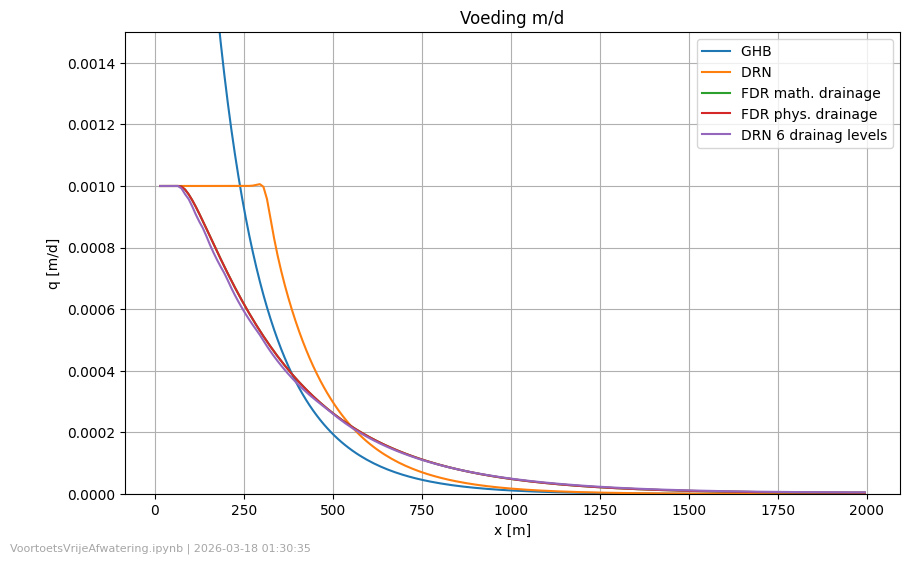

In [ ]:
# --- Basic parameters
k, D, cdr, N, h, h0, w, L = 10, 20, 200, 0.001, 0., -1.0, 1.0, 100.
phiN = h + N * cdr
lambda_ = np.sqrt(k * D * cdr)

# --- The grid (axially symmetric)
x = np.linspace(0, 2000., 201)
gr = Grid(x, None, [0., -D], axial=True)

S = gr.const(0.001)

# --- Modflow5-like boundary array
IBOUND = gr.const(1)

# --- Initial heads
HI = gr.const(h + N * cdr)

# --- Fixed flows
FQ = gr.const(N) * gr.AREA
R = 500.
Q =  -np.sum((gr.const(N) * gr.AREA)[gr.XM < R])
FQ[-1, 0, 0] += Q

# --- Instantiate the FDM model
mdl = Fdm3(gr=gr, K=gr.const(k), c=None, S=S, IBOUND=IBOUND, HI=HI, FQ=FQ)

# --- Boundary conditions of various type
GHB = np.zeros(gr.nx, dtype=Fdm3.dtype['ghb'])
GHB['Ig'], GHB['h'], GHB['C'] = gr.NOD[0, 0, :], h, gr.Area.ravel() / cdr

DRN = GHB.copy()

# --- DRNn: Mupltiple drains in cells
# --- to simulate a conductance proportional to water depth
drnlevels = 6
hdr = np.linspace(h0, phiN, drnlevels + 1)[:-1]
c = (phiN - h0) / N
C = 1 / c * (phiN - h0) / (phiN - np.mean(hdr)) / drnlevels
Ig = gr.NOD[0].flatten()
DRNn = np.zeros(drnlevels * gr.nx, dtype=Fdm3.dtype['drn'])
for i, hi in enumerate(hdr):
    i1, i2 = i * len(Ig), (i+1) * len(Ig)  
    DRNn['Ig'][i1:i2] = Ig
    DRNn['h' ][i1:i2] = hi
    DRNn['C' ][i1:i2] = gr.Area.flatten() * C

# --- Free drainage
FDR = np.zeros(gr.nx, dtype=Fdm3.dtype['fdr'])
FDR['Ig'], FDR['phi'], FDR['h'], FDR['h0'], FDR['N'] = gr.NOD[0, 0, :], h + N * cdr, h, h0, N

FDR1 = FDR.copy()
FDR2 = FDR.copy()
FDR2['w'], FDR1['L'] = w, L

# --- Simulate the model with each boundary type in turn
out_ghb = mdl.simulate(GHB=GHB)
out_drn = mdl.simulate(DRN=DRN)
out_fdr1 = mdl.simulate(FDR=FDR1)
out_fdr2 = mdl.simulate(FDR=FDR2)
out_drn1 = mdl.simulate(DRN=DRNn)

# --- Set up figure and axis for plotting
fig,(ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 10))

title = ("Axiaal-symmetrisch doorsnedemodel\n" + 
         rf"$kD={k * D}\,m^2/d,\,c_{{dr}}={cdr}\,d,\,\lambda={np.sqrt(k * D * cdr)}\,m,\,N={N}\,m/d,\,Q={Q:.3g}\,m^2/d,\,h={h}\,m,\,h_0={h0}\,m$"
)
ax1.set(title=title, ylabel='hoogte [m]')
ax2.set(title='Lek m/d', xlabel='x [m]', ylabel='lek m/d')
ax1.grid()
ax2.grid()

# --- Analytical solution according to De Glee
phi = h + N * cdr + Q / (2 * np.pi * k * D) * K0 (gr.xm / lambda_)
dqdx = Q / lambda_ * np.exp(-x / lambda_)

# --- Instantiate Blom model
Bl = wf.wBlom(aqprops={'kD':k * D, 'c': cdr})

# --- Plot the heads
ax1.plot(gr.xm, phi, label="Analytisch")
ax1.plot(gr.xm[::3], out_ghb['Phi'][-1, 0][::3], '+', label="GHB")
ax1.plot(gr.xm[::3], out_drn['Phi'][-1, 0][::3], '+', label="DRN")
ax1.plot(gr.xm, N * cdr -Bl.dd(Q=-Q, x=gr.xm, N=N), label="Blom, axiaal")

# ax2.plot(gr.x[::3], dqdx[::3] + N, label="Analytisch") # dqdx is infiltratie, N ook dus hetzelfde teken.

# --- Plot the flows
ax2.plot(gr.xm[::3], out_ghb['GHB']['q'][::3], '+', label="Lek Numeriek, GHB")
ax2.plot(gr.xm[::3], out_drn['DRN']['q'][::3], '+', label="Lek Numeriek, DRN")
ax2.plot(gr.xm, Bl.q(Q=-Q, x=gr.xm, N=N), label=f"Blom 1D, voeding (voeding + lek = N={N} m/d)")

# --- Plot the Blom radius
L = Bl.getR(Q=Q, N=N)
ymin, ymax = ax1.get_ylim()
ax1.vlines([L], ymin=ymin, ymax=ymax, colors='k', label=f"R={L:.4g} m")
ymin, ymax = ax2.get_ylim()
ax2.vlines([L], ymin=ymin, ymax=ymax, colors='k', label=f"R={L:.4g} m")

ax2.set_ylim(-2 * N, 2 * N)

ax1.legend()
ax2.legend(loc='lower right')

logo(fig, NOTEBOOK_NAME)
fig.savefig(os.path.join(dirs.images, 'example_fdm3_axym.png'))

# --- Add the numerical results for free drainage
ax1.plot(gr.xm[::3], out_fdr1['Phi'][-1, 0][::3], '+', label="FDR math. drainage")
ax1.plot(gr.xm[::3], out_fdr2['Phi'][-1, 0][::3], 'x', label="FDR phys. drainage")
ax2.plot(gr.xm[::3], out_fdr1['FDR']['q'][::3], '+',   label="FDR math. drainage")
ax2.plot(gr.xm[::3], out_fdr2['FDR']['q'][::3], 'x',   label="FDR phys. drainage")

ax1.legend()
ax2.legend(loc="lower right")

fig.savefig(os.path.join(dirs.images, 'example_fdm3_axym+FDR.png'))

ax1.plot(gr.xm[::3], out_drn1['Phi'][-1, 0][::3], '+', label="DRN 6 drain levels")

qdrn1 = np.zeros(gr.nx)
np.add.at(qdrn1, out_drn1['DRN']['Ig'], out_drn1['DRN']['q'])
ax2.plot(gr.xm[::3], qdrn1[::3], 'o', label="DRN 6 drain levels")
ax1.legend()
ax2.legend(loc='lower right')

fig.savefig(os.path.join(dirs.images, 'example_fdm3_axym+FDR+DRN1.png'))

# --- Drain discharge
fig, ax = plt.subplots(figsize=(10, 6))
ax.set(title=f"Axiaal-symmetrisch doorsndelodel. DRNn lek drnlevels={drnlevels}\n" +
       rf"$kD={k * D}\,m^2/d,\,c_{{dr}}={cdr}\,d,\,\lambda={np.sqrt(k * D * cdr)}\,m,\,N={N}\,m/d,\,Q={Q:.3g}\,m^2/d,\,h={h}\,m,\,h_0={h0}\,m$",
       xlabel="x [m]", ylabel="q [m/d]")

Ig = gr.NOD[0].flatten()
qtot = np.zeros(len(Ig), dtype=float)
drn1 = out_drn1['DRN']

for i1 in np.arange(0, len(drn1), len(Ig)):
    i2 = i1 + len(Ig)
    Ci = (drn1['C'][i1:i2] / gr.AREA.ravel()[Ig]).mean()
    hi = drn1['h'][i1:i2].mean()
    ax.plot(gr.xm, drn1['q'][i1:i2], label=fr"DRNn, $C_{{s,i}}={Ci:.3g}\,/d,\,h_i={hi:.2f}\,m$")
    qtot += drn1['q'][i1:i2]
ax.plot(gr.xm, qtot, label=fr"DRNn,  (sum of drain levels)")
ax.plot(gr.xm[::3], qdrn1[::3], '.', label="qdrn1")
drn = out_drn['DRN']
Cs = (drn['C'] / gr.AREA.ravel()[drn['Ig']]).mean()
h_ =  drn['h'].mean()
ax.plot(gr.xm, out_drn['DRN']['q'], label=fr"DRN, $C_s={Cs:.3g}\,/d,\,h_0={h_:.2f}\,m$")
ax.grid()
ax.legend(loc="center right")

logo(fig, NOTEBOOK_NAME)
fig.savefig(os.path.join(dirs.images, "example_fdm3_axym_DRNn_leakage.png"))

fig, ax = plt.subplots(figsize=(10, 6))
ax.set(title="Voeding m/d", xlabel="x [m]", ylabel="q [m/d]")

ax.plot(gr.xm[1:], out_ghb['Q' ][0, 0, 1:] / gr.AREA[0, 0, 1:], label="GHB")
ax.plot(gr.xm[1:], out_drn['Q' ][0, 0, 1:] / gr.AREA[0, 0, 1:], label="DRN")
ax.plot(gr.xm[1:], out_fdr1['Q' ][0, 0, 1:] / gr.AREA[0, 0, 1:],label="FDR math. drainage")
ax.plot(gr.xm[1:], out_fdr2['Q'][0, 0, 1:] / gr.AREA[0, 0, 1:], label="FDR phys. drainage")
ax.plot(gr.xm[1:], out_drn1['Q'][0, 0, 1:] / gr.AREA[0, 0, 1:], label="DRN 6 drain levels")
ax.set_ylim(0, 1.5e-3)
ax.grid()
ax.legend()

logo(fig, NOTEBOOK_NAME)
fig.savefig(os.path.join(dirs.images, "example_fdm3_axym_voeding.png"))

plt.plot
